## Cell 1 — Cài đặt thư viện

In [1]:
# GIỮ NGUYÊN
!pip install faiss-cpu pyvi sentence-transformers rank-bm25 pandas numpy tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.8 MB/s eta 0:00:00


In [2]:
# GIỮ NGUYÊN
!pip install fastapi uvicorn nest_asyncio matplotlib seaborn -q
!pip install langchain langchain-community langchain-huggingface -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


## Cell 2 — CONFIG TẬP TRUNG
> Gom toàn bộ path và device vào đây. Fallback local nếu không có Colab/Drive.

In [3]:
import os
import torch
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# SỬA ĐIỂM 1: Auto detect môi trường (Colab vs local)
# ─────────────────────────────────────────────
try:
    from google.colab import drive
    IS_COLAB = True
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    DRIVE_FOLDER = '/content/drive/MyDrive/RAG_Data_XuanVu'
    print("[INFO] Đang chạy trên Google Colab — Drive đã mount")
except ImportError:
    IS_COLAB = False
    DRIVE_FOLDER = './RAG_Data_XuanVu'
    print("[INFO] Đang chạy LOCAL — dùng thư mục local:", DRIVE_FOLDER)

os.makedirs(DRIVE_FOLDER, exist_ok=True)

# ─────────────────────────────────────────────
# SỬA ĐIỂM 1: Auto detect cuda/cpu
# ─────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE.upper()} {'(GPU)' if DEVICE == 'cuda' else '(CPU — chậm hơn nhưng vẫn chạy được)'}")

# ─────────────────────────────────────────────
# CẤU HÌNH ĐƯỜNG DẪN — chỉ sửa ở đây nếu cần
# ─────────────────────────────────────────────
RAW_DATA_PATH   = f"{DRIVE_FOLDER}/full_xuanvu_database.csv"
INDEX_FOLDER    = f"{DRIVE_FOLDER}/faiss_index_v2"
DOCSTORE_PATH   = f"{DRIVE_FOLDER}/docstore_v2.pkl"
EVAL_RESULT_PATH = f"{DRIVE_FOLDER}/eval_results.csv"

# ─────────────────────────────────────────────
# CẤU HÌNH MODEL
# ─────────────────────────────────────────────
# EMBED_MODEL_NAME  = 'keepitreal/vietnamese-sbert'
# RERANK_MODEL_NAME = 'cross-encoder/mmarco-mMiniLMv2-L12-H384-v1'
EMBED_MODEL_NAME = 'bkai-foundation-models/vietnamese-bi-encoder'
RERANK_MODEL_NAME = 'BAAI/bge-reranker-v2-m3'

# ─────────────────────────────────────────────
# CẤU HÌNH RETRIEVAL
# ─────────────────────────────────────────────
TOP_K_RETRIEVE = 25
TOP_K_FINAL    = 5

# ─────────────────────────────────────────────
# CẤU HÌNH CHUNKING (Điểm 10)
# ─────────────────────────────────────────────
CHUNK_IF_LONGER_THAN = 1000  # Chỉ chunk nếu review dài hơn N ký tự
CHUNK_SIZE    = 500
CHUNK_OVERLAP = 50

# ─────────────────────────────────────────────
# CẤU HÌNH BRAND
# ─────────────────────────────────────────────
BRAND_KEYWORDS = [
    "sony", "jbl", "sennheiser", "soundpeats", "anker", "edifier",
    "final", "fiio", "moondrop", "soundmagic", "akg", "bose",
    "apple", "marshall", "hifiman",
    "thieaudio", "beyerdynamic", "audio-technica", "audiotechnica",
    "unique melody", "pwaudio", "pw audio", "monster", "koss",
    "hifiman", "final", "fiio", "moondrop", "tangzu", "hiby",
    "dekoni", "hidizs", "campfire", "64 audio", "64audio",
    "empire ears", "meze", "grado", "focal", "audeze",
    "tin hifi", "tinhifi", "simgot", "dunu", "kinera",
    "letshuoer", "truthear", "7hz", "tripowin", "kz",
    "cca", "tanchjim", "yanyin", "softears"
]

print("\n[INFO] Config khởi tạo thành công!")
print(f"   RAW_DATA : {RAW_DATA_PATH}")
print(f"   INDEX    : {INDEX_FOLDER}")
print(f"   DOCSTORE : {DOCSTORE_PATH}")

Mounted at /content/drive
[INFO] Đang chạy trên Google Colab — Drive đã mount
🖥️  Device: CUDA (GPU)

[INFO] Config khởi tạo thành công!
   RAW_DATA : /content/drive/MyDrive/RAG_Data_XuanVu/full_xuanvu_database.csv
   INDEX    : /content/drive/MyDrive/RAG_Data_XuanVu/faiss_index_v2
   DOCSTORE : /content/drive/MyDrive/RAG_Data_XuanVu/docstore_v2.pkl


## Cell 3 — SHARED UTILS (SỬA: Điểm 2 + 9)
> `clean_vietnamese_text()` chỉ định nghĩa một lần tại đây. Tất cả cell sau đều import từ đây.

In [4]:
import re
import pandas as pd
import numpy as np
from pyvi import ViTokenizer

# ─────────────────────────────────────────────
# SỬA ĐIỂM 2: Hàm duy nhất, dùng chung cho build index / query / evaluation
# ─────────────────────────────────────────────
def clean_vietnamese_text(text):
    """Chuẩn hoá + tokenize tiếng Việt (PyVi). Dùng chung toàn bộ pipeline."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'[^\w\s.,?!/]', '', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return ViTokenizer.tokenize(text)

def normalize_url(url):
    """Chuẩn hoá URL để so khớp ground-truth ổn định hơn."""
    url = str(url or '').strip().lower()
    url = url.split('?')[0].split('#')[0].rstrip('/')
    if url.endswith('.html'):
        url = url[:-5]
    return url

def clean_price(price_str):
    """Chuyển chuỗi giá về số nguyên."""
    if pd.isna(price_str):
        return 0
    price_num = re.sub(r'[^\d]', '', str(price_str))
    return int(price_num) if price_num else 0

def extract_brand(text):
    """Trích thương hiệu từ text bằng danh sách brand; ưu tiên brand dài trước."""
    text_lower = str(text or '').lower()
    for b in sorted(BRAND_KEYWORDS, key=len, reverse=True):
        if b in text_lower:
            return b
    return "khác"

def detect_query_brands(query):
    """Tìm các brand được nhắc trong query."""
    q = str(query or '').lower()
    return [b for b in sorted(set(BRAND_KEYWORDS), key=len, reverse=True) if b in q]

def parse_price_constraint(query):
    """
    Parse điều kiện giá đơn giản từ query.
    Hỗ trợ: dưới 500k, dưới 1tr, dưới 1 triệu, tầm/khoảng 2.5 triệu, 2,5 triệu đổ lại.
    Trả về max_price dạng int VND hoặc None.
    """
    q = str(query or '').lower().replace(',', '.')
    patterns = [
        r'(?:dưới|duoi|<=|không quá|khong qua|ít hơn|it hon|tối đa|toi da)\s*(\d+(?:\.\d+)?)\s*(triệu|tr|m|k|ngàn|nghìn)',
        r'(?:tầm|tam|khoảng|khoang|around)\s*(\d+(?:\.\d+)?)\s*(triệu|tr|m|k|ngàn|nghìn)',
        r'(\d+(?:\.\d+)?)\s*(triệu|tr|m|k|ngàn|nghìn)\s*(?:đổ lại|do lai|trở xuống|tro xuong)',
    ]
    for pat in patterns:
        m = re.search(pat, q)
        if not m:
            continue
        val = float(m.group(1))
        unit = m.group(2)
        if unit in ['triệu', 'tr', 'm']:
            return int(val * 1_000_000)
        if unit in ['k', 'ngàn', 'nghìn']:
            return int(val * 1_000)
    return None

def price_ok(doc_price, max_price):
    """Kiểm tra giá có thỏa max_price không. Nếu không có constraint thì True."""
    if max_price is None:
        return True
    try:
        p = int(doc_price)
    except Exception:
        p = 0
    return p > 0 and p <= max_price

# ─────────────────────────────────────────────
# SỬA ĐIỂM 9: Helper kiểm tra guard chung
# ─────────────────────────────────────────────
def check_file_exists(path, label="File"):
    if not os.path.exists(path):
        print(f"[ERROR] KHÔNG TÌM THẤY {label}: {path}")
        return False
    print(f"[INFO] {label} tồn tại: {path}")
    return True

def check_metadata_fields(doc, required_fields):
    """Kiểm tra metadata của document có đủ trường không."""
    missing = [f for f in required_fields if f not in doc.metadata]
    if missing:
        print(f"[WARNING]  Metadata thiếu trường: {missing}")
        return False
    return True

def dedup_by_url(docs):
    """
    Giữ lại 1 document đại diện cho mỗi URL (chunk tốt nhất = chunk đầu tiên sau rerank).
    Tránh cùng 1 sản phẩm chiếm nhiều slot trong Top K.
    """
    seen_urls = {}
    for doc in docs:
        url = doc.metadata.get('url', doc.metadata.get('product_name', ''))
        if url not in seen_urls:
            seen_urls[url] = doc
    result = list(seen_urls.values())
    return result

print("[INFO] Shared utils đã sẵn sàng (clean_vietnamese_text, extract_brand, clean_price, guards)")

[INFO] Shared utils đã sẵn sàng (clean_vietnamese_text, extract_brand, clean_price, guards)


## Cell 4 — Web Scraper (GIỮ NGUYÊN — commented out)

In [6]:
# GIỮ NGUYÊN — Web scraper (bỏ comment để chạy lại nếu cần cào dữ liệu mới)

import requests
from bs4 import BeautifulSoup
import time
import random
import concurrent.futures

BASE_DOMAIN = "https://tainghe.com.vn"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "vi-VN,vi;q=0.9,en-US;q=0.8,en;q=0.7",
}
MAX_THREADS = 20

def get_all_subcategories():
    print("--- ĐANG LỌC DANH MỤC TRÊN TRANG CHỦ ---")
    sub_categories = set()
    try:
        response = requests.get(BASE_DOMAIN, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(response.text, 'html.parser')
        menu_items = soup.find_all('a')
        for item in menu_items:
            href = item.get('href', '')
            if href.endswith('.html') and not href.startswith('http'):
                full_link = BASE_DOMAIN + href if href.startswith('/') else BASE_DOMAIN + '/' + href
                if any(keyword in href for keyword in ['tai-nghe', 'may-nghe-nhac', 'dac-amp', 'loa', 'phu-kien', 'hi-end-cables']):
                    sub_categories.add(full_link)
        print(f"[OK] Đã chốt được {len(sub_categories)} link danh mục.")
        return list(sub_categories)
    except Exception as e:
        print(f"[LỖI] Lọc danh mục thất bại: {e}")
        return []

def get_product_links_from_category(category_url, max_pages_per_cat=50):
    product_links = set()
    for page in range(1, max_pages_per_cat + 1):
        url = f"{category_url}?page={page}"
        try:
            response = requests.get(url, headers=HEADERS, timeout=10)
            soup = BeautifulSoup(response.text, 'html.parser')
            items = soup.find_all('a', class_='p-name')
            if not items:
                break
            for item in items:
                link = item.get('href')
                if link:
                    full_link = link if "http" in link else BASE_DOMAIN + link
                    product_links.add(full_link)
            time.sleep(random.uniform(0.5, 1.5))
        except Exception as e:
            break
    return list(product_links)

def fetch_product_details(url):
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        name_tag = soup.find('h1', id='detail-name')
        name = name_tag.text.strip() if name_tag else "Unknown"
        price_tag = soup.find('span', class_='price_config')
        price = price_tag.text.strip() if price_tag else "Contact"
        brand = "Unknown"
        candidates = soup.find_all(lambda t: t.name in ['li', 'p', 'div', 'tr', 'span', 'b', 'strong']
                                   and t.get_text()
                                   and 'thương hiệu' in t.get_text().lower())
        if candidates:
            candidates_sorted = sorted(candidates, key=lambda t: len(t.get_text(strip=True)))
            for tag in candidates_sorted:
                text = tag.get_text(separator=' ', strip=True)
                match = re.search(r'thương\s*hiệu\s*[:\-]?\s*(.+)', text, re.IGNORECASE)
                if match:
                    extracted = match.group(1).strip()
                    if extracted and len(extracted) < 30:
                        brand = extracted
                        break
        content_tag = soup.find('div', class_='emtry_content')
        content = content_tag.text.strip() if content_tag else ""
        time.sleep(random.uniform(1.0, 2.5))
        if content and name != "Unknown":
            print(f"[XONG] {name[:30]:<30} | Hãng: {brand:<15} | Giá: {price}")
            return {"url": url, "product_name": name, "brand": brand, "price": price, "review_content": content}
        return None
    except Exception as e:
        print(f"[LỖI] {url} -> {e}")
        return None

def run_full_scraper():
    start_time = time.time()
    categories = get_all_subcategories()
    if not categories:
        return
    print(f"\n--- BƯỚC 2: ĐANG GOM LINK TỪ {len(categories)} DANH MỤC ---")
    all_product_links = set()
    for i, cat_url in enumerate(categories):
        print(f"Đang lật trang danh mục [{i+1}/{len(categories)}]: {cat_url}")
        links = get_product_links_from_category(cat_url)
        all_product_links.update(links)
    product_links_list = list(all_product_links)
    print(f"\n✅ TỔNG CỘNG ĐÃ GOM ĐƯỢC: {len(product_links_list)} LINK SẢN PHẨM KHÁC NHAU.")
    print(f"\n--- BƯỚC 3: BẮT ĐẦU BÓC TÁCH CHI TIẾT BẰNG {MAX_THREADS} THREADS ---")
    final_data = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
        future_to_url = {executor.submit(fetch_product_details, url): url for url in product_links_list}
        for future in concurrent.futures.as_completed(future_to_url):
            data = future.result()
            if data:
                final_data.append(data)
    drive_save_path = RAW_DATA_PATH
    df = pd.DataFrame(final_data)
    df.to_csv(drive_save_path, index=False, encoding='utf-8-sig')
    end_time = time.time()
    print(f"\nHOÀN THÀNH CÀO DỮ LIỆU! {len(final_data)} sản phẩm — {round((end_time - start_time)/60, 2)} phút.")

# if __name__ == "__main__":
#     run_full_scraper()

## Cell 5 — EDA (GIỮ NGUYÊN)

 BẮT ĐẦU KHÁM PHÁ DỮ LIỆU (EDA)
[INFO] RAW_DATA tồn tại: /content/drive/MyDrive/RAG_Data_XuanVu/full_xuanvu_database.csv
   Tổng số sản phẩm: 2350
   Số thương hiệu nhận diện được: 44


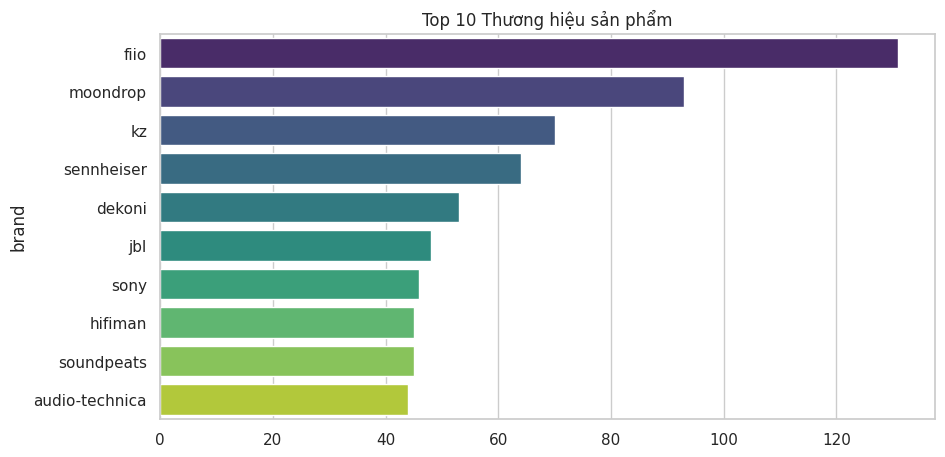

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def run_eda():
    print(" BẮT ĐẦU KHÁM PHÁ DỮ LIỆU (EDA)")
    if not check_file_exists(RAW_DATA_PATH, "RAW_DATA"):
        return
    df = pd.read_csv(RAW_DATA_PATH)
    df['brand'] = df['product_name'].apply(extract_brand)
    print(f"   Tổng số sản phẩm: {len(df)}")
    print(f"   Số thương hiệu nhận diện được: {df[df['brand'] != 'khác']['brand'].nunique()}")
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))
    top_brands = df[df['brand'] != 'khác']['brand'].value_counts().head(10)
    sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='viridis', legend=False)
    plt.title('Top 10 Thương hiệu sản phẩm')
    plt.show()

run_eda()

## Cell 6 — PREPARE DATA (SỬA: Điểm 7 + 10)
> Tách riêng bước chuẩn bị dữ liệu. Chiến lược: 1 sản phẩm = 1 document, chỉ chunk nếu review quá dài.

In [8]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm.auto import tqdm

def prepare_data():
    """
    Chuẩn bị dữ liệu cho retrieval.
    Mặc định: 1 sản phẩm = 1 document.
    Chỉ chunk khi review quá dài để tránh 1 sản phẩm bị phân mảnh không cần thiết.
    """
    if not check_file_exists(RAW_DATA_PATH, "RAW_DATA"):
        return None

    df = pd.read_csv(RAW_DATA_PATH)
    print(f"📂 Đọc dữ liệu: {len(df)} sản phẩm")
    print(f"   Các cột: {list(df.columns)}")

    required_cols = ['product_name', 'review_content', 'price', 'url']
    for col in required_cols:
        if col not in df.columns:
            print(f"[ERROR] Thiếu cột bắt buộc: {col}")
            return None

    df = df.dropna(subset=['product_name', 'review_content'])
    print(f"   Sau khi lọc NaN: {len(df)} sản phẩm hợp lệ")

    df['price_num'] = df['price'].apply(clean_price)
    # Ưu tiên cột brand nếu dataset đã có; nếu thiếu thì extract từ product_name.
    if 'brand' in df.columns:
        df['brand'] = df['brand'].fillna('').astype(str).str.lower()
        missing_brand = df['brand'].isin(['', 'nan', 'none', 'khác'])
        df.loc[missing_brand, 'brand'] = df.loc[missing_brand, 'product_name'].apply(extract_brand)
    else:
        df['brand'] = df['product_name'].apply(extract_brand)

    # Splitter dùng khi review quá dài
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ".", " "]
    )

    documents = []
    n_chunked = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preparing documents"):
        raw_name    = str(row['product_name'])
        raw_review  = str(row['review_content'])
        raw_price   = str(row['price'])
        raw_brand   = str(row['brand'])
        price_num   = price_num  = int(row['price_num']) if not pd.isna(row['price_num']) else 0
        url         = str(row.get('url', ''))

        # Nhúng brand + price vào page_content để FAISS & BM25 đều thấy.
        # Cấu trúc rõ ràng giúp BM25 match keyword đúng hơn.
        structured_raw = (
            f"Sản phẩm: {raw_name}. "
            f"Thương hiệu: {raw_brand}. "
            f"Giá: {raw_price}. "
            f"{raw_review}"
        )

        metadata_base = {
            "product_name":    raw_name,
            "brand":           raw_brand,
            "price":           price_num,
            "url":             url,
            "normalized_url": normalize_url(url),
            "original_content": structured_raw
        }

        # Chỉ chunk nếu review quá dài
        if len(raw_review) > CHUNK_IF_LONGER_THAN:
            n_chunked += 1
            raw_chunks = text_splitter.split_text(structured_raw)
            for chunk in raw_chunks:
                # SỬA ĐIỂM 2: Dùng clean_vietnamese_text chung
                clean_chunk = clean_vietnamese_text(chunk)
                if clean_chunk.strip():
                    documents.append(Document(
                        page_content=clean_chunk,
                        metadata={**metadata_base, "original_content": chunk}
                    ))
            for chunk_id, chunk in enumerate(text_splitter.split_text(structured_raw)):
                clean_chunk = clean_vietnamese_text(chunk)
                if clean_chunk.strip():
                    documents.append(Document(
                        page_content=clean_chunk,
                        metadata={**metadata_base, "chunk_id": chunk_id, "original_content": chunk}
                    ))
        else:
            # 1 sản phẩm = 1 document
            clean_doc = clean_vietnamese_text(structured_raw)
            if clean_doc.strip():
                documents.append(Document(
                    page_content=clean_doc,
                    metadata={**metadata_base, "chunk_id": 0}
                ))

    print(f"\n[INFO] Chuẩn bị xong:")
    print(f"   Tổng documents: {len(documents)}")
    print(f"   Sản phẩm được chunk (review dài): {n_chunked}")
    print(f"   Sản phẩm giữ nguyên (1 doc): {len(df) - n_chunked}")

    return documents

print("[INFO] Hàm prepare_data() đã định nghĩa.")

[INFO] Hàm prepare_data() đã định nghĩa.


## Cell 7 — BUILD INDEX (SỬA: Điểm 7 + 9)

In [9]:
import pickle
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

def build_index(documents):
    """
    SỬA ĐIỂM 7: Tách riêng bước build index.
    SỬA ĐIỂM 9: Log chi tiết từng bước.
    """
    if documents is None or len(documents) == 0:
        print("[ERROR] Không có documents để build index!")
        return None

    print(f"[RUNNING] Bắt đầu build index với {len(documents)} documents...")

    # SỬA ĐIỂM 1: Dùng DEVICE từ config
    lc_embedder = HuggingFaceEmbeddings(
        model_name=EMBED_MODEL_NAME,
        model_kwargs={'device': DEVICE}
    )

    texts     = [doc.page_content for doc in documents]
    metadatas = [doc.metadata for doc in documents]

    print(f"   Đang encode {len(texts)} texts bằng {DEVICE.upper()}...")
    fast_embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
    batch = 256 if DEVICE == 'cuda' else 32
    embeddings_matrix = fast_embedder.encode(texts, batch_size=batch, show_progress_bar=True)

    print("\n[RUNNING] Đóng gói vào FAISS...")
    text_embedding_pairs = list(zip(texts, embeddings_matrix.tolist()))
    vector_store = FAISS.from_embeddings(
        text_embeddings=text_embedding_pairs,
        embedding=lc_embedder,
        metadatas=metadatas
    )

    print(f"[INFO] Lưu index vào: {INDEX_FOLDER}")
    vector_store.save_local(INDEX_FOLDER)
    with open(DOCSTORE_PATH, "wb") as f:
        pickle.dump(documents, f)

    print(f"[INFO] Build index hoàn thành! ({len(documents)} vectors)")
    return vector_store

print("[INFO] Hàm build_index() đã định nghĩa.")

[INFO] Hàm build_index() đã định nghĩa.


## Cell 8 — LOAD INDEX (SỬA: Điểm 7 + 9)

In [10]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

def load_index():
    """
    SỬA ĐIỂM 7: Tách riêng bước load.
    SỬA ĐIỂM 9: Guard kiểm tra file tồn tại.
    """
    if not check_file_exists(INDEX_FOLDER, "INDEX_FOLDER"):
        return None, None, None, None
    if not check_file_exists(DOCSTORE_PATH, "DOCSTORE"):
        return None, None, None, None

    print("\n⏳ Đang tải Embedding model...")
    embeddings = HuggingFaceEmbeddings(
        model_name=EMBED_MODEL_NAME,
        model_kwargs={'device': DEVICE}  # SỬA ĐIỂM 1
    )
    vector_store = FAISS.load_local(INDEX_FOLDER, embeddings, allow_dangerous_deserialization=True)

    with open(DOCSTORE_PATH, "rb") as f:
        all_docs = pickle.load(f)

    # SỬA ĐIỂM 9: Kiểm tra metadata đủ trường
    REQUIRED_FIELDS = ['product_name', 'brand', 'price', 'url', 'original_content']
    bad_docs = [i for i, d in enumerate(all_docs) if not check_metadata_fields(d, REQUIRED_FIELDS)]
    if bad_docs:
        print(f"[WARNING]  {len(bad_docs)} documents thiếu metadata — có thể ảnh hưởng reranking")
    else:
        print(f"[INFO] Tất cả {len(all_docs)} documents có đủ metadata")

    # SỬA ĐIỂM 8: BM25 tokenize chuẩn PyVi (page_content đã được tokenize khi build)
    print("[RUNNING] Đang khởi tạo BM25 (dùng page_content đã tokenize PyVi)...")
    tokenized_corpus = [doc.page_content.split() for doc in all_docs]
    bm25 = BM25Okapi(tokenized_corpus)
    print(f"   BM25 vocab size: {len(bm25.idf)} terms")

    print("[RUNNING] Đang tải Reranker...")
    reranker = CrossEncoder(RERANK_MODEL_NAME, device=DEVICE)  # SỬA ĐIỂM 1

    print(f"\n[INFO] Hệ thống Retrieval sẵn sàng! ({len(all_docs)} docs trong index)")
    return vector_store, bm25, reranker, all_docs

print("[INFO] Hàm load_index() đã định nghĩa.")

[INFO] Hàm load_index() đã định nghĩa.


## Cell 9 — AUTO INIT: Build nếu chưa có, Load nếu đã có (SỬA: Điểm 7)

In [11]:
index_exists = os.path.exists(INDEX_FOLDER) and os.path.exists(DOCSTORE_PATH)

if not index_exists:
    print("🚀 Chưa có Index — bắt đầu build từ đầu...")
    all_docs_prepared = prepare_data()
    vector_store = build_index(all_docs_prepared)
    # Load lại sau khi build để có bm25 & reranker
    vector_store, bm25, reranker, all_docs = load_index()
else:
    print("ℹ️  Index đã tồn tại — load trực tiếp...")
    vector_store, bm25, reranker, all_docs = load_index()

ℹ️  Index đã tồn tại — load trực tiếp...
[INFO] INDEX_FOLDER tồn tại: /content/drive/MyDrive/RAG_Data_XuanVu/faiss_index_v2
[INFO] DOCSTORE tồn tại: /content/drive/MyDrive/RAG_Data_XuanVu/docstore_v2.pkl

⏳ Đang tải Embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]


[INFO] Hệ thống Retrieval sẵn sàng! (36227 docs trong index)


## Cell 10 — RETRIEVE DENSE (SỬA: Điểm 7)

In [12]:
def retrieve_dense(query, vector_store, k=TOP_K_RETRIEVE):
    clean_q = clean_vietnamese_text(query)
    # Lấy k*4 để sau dedup vẫn còn đủ k docs
    raw = vector_store.similarity_search(clean_q, k=k * 4)
    return dedup_by_url(raw)[:k]

print("[INFO] Hàm retrieve_dense() đã định nghĩa.")

[INFO] Hàm retrieve_dense() đã định nghĩa.


## Cell 11 — RETRIEVE HYBRID (SỬA: Điểm 4 + 7 + 9)

In [13]:
def retrieve_hybrid(query, vector_store, bm25, all_docs, k_retrieve=50, verbose=False):
    """
    SỬA ĐIỂM 4: Dedup dùng 'url' thay vì 'original_content'.
    SỬA ĐIỂM 7: Tách hàm riêng (chưa có reranking — xem rerank_candidates).
    SỬA ĐIỂM 9: Log số candidate dense/sparse.
    SỬA LỖI HIỆU SUẤT: Đổi k_retrieve mặc định thành 50 (Lấy Rộng) để Reranker có đủ ứng viên chấm điểm thay vì chỉ lấy Top 5.
    """
    # SỬA ĐIỂM 2: Dùng clean_vietnamese_text chung
    clean_q = clean_vietnamese_text(query)

    # Dense Search
    dense_docs = vector_store.similarity_search(clean_q, k=k_retrieve)

    # SỬA ĐIỂM 8: BM25 query cũng được tokenize chuẩn PyVi
    tokenized_query = clean_q.split()
    sparse_docs = bm25.get_top_n(tokenized_query, all_docs, n=k_retrieve)

    if verbose:
        print(f"   Dense candidates : {len(dense_docs)}")
        print(f"   Sparse candidates: {len(sparse_docs)}")

    # SỬA ĐIỂM 4: Dedup dùng URL (key duy nhất) thay vì original_content
    unique_docs = {}
    for doc in (dense_docs + sparse_docs):
        url_key = doc.metadata.get('url', doc.metadata.get('original_content', ''))
        if url_key not in unique_docs:
            unique_docs[url_key] = doc

    all_candidates = list(unique_docs.values())

    if verbose:
        print(f"   Sau dedup        : {len(all_candidates)} unique candidates")

    return all_candidates

print("✅ Hàm retrieve_hybrid() đã định nghĩa.")

✅ Hàm retrieve_hybrid() đã định nghĩa.


## Cell 12 — RERANK + METADATA BONUS (SỬA: Điểm 3 + 7 + 9)

In [14]:

def rerank_candidates(query, candidates, reranker, top_k=TOP_K_FINAL, verbose=False):
    """
    Cross-encoder rerank + metadata-aware scoring.
    Điểm cuối = điểm reranker + brand bonus - price penalty.
    """
    if not candidates:
        print("⚠️ Không có candidates để rerank!")
        return []

    pairs = [[query, doc.metadata.get('original_content', doc.page_content)] for doc in candidates]
    rerank_scores = reranker.predict(pairs)

    query_brands = detect_query_brands(query)
    max_price = parse_price_constraint(query)

    for i, (score, doc) in enumerate(zip(rerank_scores, candidates)):
        bonus = 0.0

        # Brand bonus: nếu query nhắc brand và document đúng brand.
        doc_brand = str(doc.metadata.get('brand', '')).lower()
        doc_text = (str(doc.metadata.get('product_name', '')) + ' ' + str(doc.metadata.get('original_content', ''))).lower()
        if query_brands:
            if any((b == doc_brand) or (b in doc_text) for b in query_brands):
                bonus += 0.5
            else:
                # phạt nhẹ nếu query yêu cầu brand rõ nhưng doc không match brand
                bonus -= 0.2

        # Price penalty: nếu query có điều kiện giá mà sản phẩm vượt giá.
        doc_price = doc.metadata.get('price', 0)
        if max_price is not None and not price_ok(doc_price, max_price):
            bonus -= 1.0

        doc.metadata['rerank_score'] = float(score) + bonus
        doc.metadata['rerank_raw'] = float(score)
        doc.metadata['meta_bonus'] = bonus
        doc.metadata['detected_max_price'] = max_price
        doc.metadata['detected_query_brands'] = query_brands

    sorted_all = sorted(candidates, key=lambda x: x.metadata.get('rerank_score', -999), reverse=True)
    deduped = dedup_by_url(sorted_all)[:top_k]

    if verbose:
        print(f"   Rerank hoàn thành — Top {top_k} kết quả:")
        for d in deduped:
            print(f"     [{d.metadata.get('rerank_score', 0):.3f}] raw={d.metadata.get('rerank_raw', 0):.3f}, "
                  f"bonus={d.metadata.get('meta_bonus', 0):+.1f} | {d.metadata.get('product_name', '')[:60]}")

    return deduped

print("[INFO] Hàm rerank_candidates() đã định nghĩa.")


[INFO] Hàm rerank_candidates() đã định nghĩa.


## Cell 13 - Chạy thử để xem score từng truy vấn

In [ ]:
def run_interactive_session():
    """Chạy demo tìm kiếm tương tác. Gọi hàm này thủ công khi cần demo."""
    if vector_store is None:
        print("❌ Chưa load index. Hãy chạy Cell 9 trước.")
        return

    while True:
        user_query = input("Nhập câu hỏi tìm kiếm (hoặc gõ 'exit' để thoát): ")
        if user_query.lower() in ['exit', 'quit', 'thoát']:
            print("Tạm biệt!")
            break
        if not user_query.strip():
            continue

        print("\nĐang tìm kiếm...")
        candidates = retrieve_hybrid(user_query, vector_store, bm25, all_docs, verbose=True)
        results = rerank_candidates(user_query, candidates, reranker, verbose=True)

        print(f"Bảng 3.3: Top-5 kết quả cho truy vấn \"{user_query}\"\n")
        print(f"{'Hạng':<5} | {'Sản phẩm':<38} | {'Score':<5} | {'Liên quan?'}")

        for idx, doc in enumerate(results[:5], 1):
            product = doc.metadata.get('product_name', 'N/A')
            score = doc.metadata.get('rerank_score', 0)
            doc_brand = str(doc.metadata.get('brand', '')).lower()

            q_lower = user_query.lower()
            p_lower = product.lower()

            # Cắt gọn tên sản phẩm nếu quá dài để không bị vỡ bảng
            short_product = product[:35] + "..." if len(product) > 38 else product

            # In từng dòng với định dạng căn lề
            print(f"{idx:<5} | {short_product:<38} | {score:<5.2f}")
print("[INFO] Hàm run_interactive_session() đã định nghĩa. Bỏ comment để chạy demo.")

Nhập câu hỏi tìm kiếm (hoặc gõ 'exit' để thoát): ThieAudio Oracle MKII

Đang tìm kiếm...
   Dense candidates : 50
   Sparse candidates: 50
   Sau dedup        : 11 unique candidates
   Rerank hoàn thành — Top 5 kết quả:
     [1.497] raw=0.997, bonus=+0.5 | Tai nghe ThieAudio Oracle MKII
     [1.484] raw=0.984, bonus=+0.5 | Tai nghe ThieAudio Oracle MKIII
     [1.430] raw=0.930, bonus=+0.5 | Tai nghe ThieAudio Elixir
     [1.362] raw=0.862, bonus=+0.5 | Tai nghe ThieAudio Hype 4 MKII
     [1.030] raw=0.530, bonus=+0.5 | Tai nghe ThieAudio Monarch MKIII
Bảng 3.3: Top-5 kết quả cho truy vấn "ThieAudio Oracle MKII"

Hạng  | Sản phẩm                               | Score | Liên quan?
1     | Tai nghe ThieAudio Oracle MKII         | 1.50  |    ≈
2     | Tai nghe ThieAudio Oracle MKIII        | 1.48  |    ✓
3     | Tai nghe ThieAudio Elixir              | 1.43  |    ≈
4     | Tai nghe ThieAudio Hype 4 MKII         | 1.36  |    ≈
5     | Tai nghe ThieAudio Monarch MKIII       | 1.03  |    ≈


KeyboardInterrupt: Interrupted by user

In [15]:
# ============================
# FIX nDCG@K: đảm bảo nDCG nằm trong [0, 1]
# Paste cell này trước cell run_evaluation()
# ============================

import math
import numpy as np

def ndcg_at_k(docs, item, k=5, all_docs=None):
    """
    Tính nDCG@K đúng chuẩn:
    - DCG: điểm ranking hiện tại
    - IDCG: điểm ranking lý tưởng
    - nDCG = DCG / IDCG, luôn nằm trong [0, 1]
    """

    top_docs = docs[:k]

    # relevance nhị phân: relevant = 1, non-relevant = 0
    gains = [1 if is_relevant(doc, item) else 0 for doc in top_docs]

    # DCG
    dcg = 0.0
    for i, rel in enumerate(gains, start=1):
        dcg += rel / math.log2(i + 1)

    # Đếm số relevant lý tưởng
    # Ưu tiên ground-truth URL nếu có
    gt_urls = item.get("relevant_urls", [])

    if gt_urls:
        total_relevant = len(set(gt_urls))
    elif all_docs is not None:
        total_relevant = sum(1 for doc in all_docs if is_relevant(doc, item))
    else:
        # fallback an toàn: ít nhất bằng số relevant xuất hiện trong top-k
        total_relevant = sum(gains)

    # Guard để tránh DCG > IDCG khi dùng weak-label / keyword fallback
    total_relevant = max(total_relevant, sum(gains))

    ideal_hits = min(k, total_relevant)

    if ideal_hits == 0:
        return 0.0

    # IDCG lý tưởng: tất cả relevant đứng trên đầu
    idcg = 0.0
    for i in range(1, ideal_hits + 1):
        idcg += 1.0 / math.log2(i + 1)

    if idcg == 0:
        return 0.0

    score = dcg / idcg

    # nDCG chuẩn không được vượt quá 1
    return min(score, 1.0)

## Cell 15 — EVALUATION ĐÚNG CHUẨN (SỬA: Điểm 5 + 6)
> Thay `score_mock` bằng các metric chuẩn: Precision@5, HitRate@5, MRR, nDCG@5.
> Benchmark cả hai cấu hình: Dense vs Hybrid+Rerank.

In [16]:

import math
import pandas as pd

# ============================================================
# EVALUATION SET
# ============================================================
TEST_QUERIES = [
    {
        "query": "Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-no-5-dong-occ-litz.html"],
        "relevant_keywords": ["no.5", "đồng occ", "litz"]
    },
    {
        "query": "Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu",
        "relevant_urls": [],
        "relevant_keywords": ["pwaudio", "dây cáp", "cáp tai nghe"]
    },
    {
        "query": "Các dòng cáp Century Series The 1960s của PWAudio có tốt không?",
        "relevant_urls": [
            "https://tainghe.com.vn/pwaudio-century-series-the-1960s-chinh-hang.html",
            "https://tainghe.com.vn/pwaudio-monile-mkii-ft.60s.html"
        ],
        "relevant_keywords": ["century series", "1960s", "ft.60s"]
    },
    {
        "query": "Dây nâng cấp âm thanh Ignit mạ bạc cho in-ear",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-titans-series-ignis-10pcs.html"],
        "relevant_keywords": ["ignis", "titans series", "dây nâng cấp"]
    },
    {
        "query": "Cho tôi thông tin về cáp PWAudio Monile MKII bản có Shielding chống nhiễu",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-monile-mkii-shielding.html"],
        "relevant_keywords": ["monile mkii", "shielding", "chống nhiễu"]
    },
    {
        "query": "Tôi muốn nâng cấp dây dẫn bằng đồng nguyên chất cho tai nghe",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-no-5-dong-occ-litz.html"],
        "relevant_keywords": ["đồng occ", "đồng nguyên chất", "copper"]
    },
    {
        "query": "Tìm cho tôi tai nghe ThieAudio Oracle MKIII",
        "relevant_urls": ["https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html"],
        "relevant_keywords": ["thieaudio", "oracle", "mkiii"]
    },
    {
        "query": "Có mẫu loa đeo cổ Monster nào giá dưới 2 triệu không?",
        "relevant_urls": [],
        "relevant_keywords": ["monster", "loa đeo cổ", "boomerang"]
    },
    {
        "query": "Tôi cần tìm dây cáp ddHiFi cổng 4.4mm có cấu tạo lõi bạc và OCC",
        "relevant_urls": ["https://tainghe.com.vn/ddhifi-bc44pro-4-4mm-balanced-cable.html"],
        "relevant_keywords": ["ddhifi", "bc44pro", "4.4mm", "silver", "occ", "bạc"]
    },
    {
        "query": "Bên shop có bán mút tai nghe thay thế cho con chụp tai Sony 10RBT không?",
        "relevant_urls": ["https://tainghe.com.vn/sony-mdr-10rbt-ear-pads.html"],
        "relevant_keywords": ["đệm pad", "sony", "mdr-10rbt", "mdr -10rbt"]
    },
    {
        "query": "Cho tôi xin mẫu tai nghe in-ear cấu hình tribrid có tích hợp công nghệ IMPACT",
        "relevant_urls": ["https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html"],
        "relevant_keywords": ["tribrid", "impact", "oracle mkiii"]
    },
    {
        "query": "FiiO JD7",
        "relevant_urls": ["https://tainghe.com.vn/tai-nghe-fiio-jade-audio-jd7.html"],
        "relevant_keywords": ["fiio", "jade audio", "jd7"]
    }
]

print(f"[INFO] Đã load {len(TEST_QUERIES)} câu hỏi vào tập đánh giá.")

# ============================================================
# RELEVANCE RULES
# ============================================================
def keyword_match(doc, keywords):
    doc_name = str(doc.metadata.get('product_name', '')).lower()
    doc_content = str(doc.metadata.get('original_content', '')).lower()
    return any(str(kw).lower() in doc_name or str(kw).lower() in doc_content for kw in keywords)

def is_relevant(doc, item):
    """
    Binary relevance cho metric chính.
    - Nếu có relevant_urls: chỉ tính đúng khi URL match chính xác.
    - Nếu không có URL: dùng keyword fallback cho query open-ended.
    """
    relevant_urls = [normalize_url(u) for u in item.get('relevant_urls', []) if str(u).strip()]
    doc_url = normalize_url(doc.metadata.get('url', ''))

    if relevant_urls:
        return doc_url in relevant_urls

    return keyword_match(doc, item.get('relevant_keywords', []))

def count_relevant_in_universe(item, universe_docs):
    """
    Số relevant docs trong toàn bộ docstore để tính IDCG đúng.
    Quan trọng: giúp nDCG luôn nằm trong [0, 1].
    """
    if universe_docs is None:
        return len(item.get('relevant_urls', []))

    # Đếm theo URL để tránh 1 sản phẩm nhiều chunk làm phình relevant set.
    relevant_urls = set()
    for d in universe_docs:
        if is_relevant(d, item):
            relevant_urls.add(normalize_url(d.metadata.get('url', '')))
    return len(relevant_urls)

# ============================================================
# METRICS
# ============================================================
def precision_at_k(docs, item, k):
    return sum(1 for d in docs[:k] if is_relevant(d, item)) / k

def hit_rate_at_k(docs, item, k):
    return 1.0 if any(is_relevant(d, item) for d in docs[:k]) else 0.0

def mrr_at_k(docs, item, k):
    for i, doc in enumerate(docs[:k], 1):
        if is_relevant(doc, item):
            return 1.0 / i
    return 0.0

def ndcg_at_k(docs, item, k, universe_docs=None):
    dcg = 0.0
    for i, d in enumerate(docs[:k], start=1):
        rel = 1.0 if is_relevant(d, item) else 0.0
        dcg += rel / math.log2(i + 1)

    n_rel = count_relevant_in_universe(item, universe_docs)
    ideal_hits = min(n_rel, k)
    if ideal_hits <= 0:
        return 0.0

    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, ideal_hits + 1))
    value = dcg / idcg if idcg > 0 else 0.0
    return min(value, 1.0)  # safety clamp; nếu >1 thì metric đang có vấn đề

# ============================================================
# OPTIONAL CONSTRAINT METRICS
# ============================================================
def price_constraint_rate_for_results(query, docs):
    max_price = parse_price_constraint(query)
    if max_price is None or not docs:
        return None
    return sum(1 for d in docs if price_ok(d.metadata.get('price', 0), max_price)) / len(docs)

def brand_match_rate_for_results(query, docs):
    query_brands = detect_query_brands(query)
    if not query_brands or not docs:
        return None
    ok = 0
    for d in docs:
        text = (str(d.metadata.get('product_name', '')) + ' ' + str(d.metadata.get('original_content', ''))).lower()
        brand = str(d.metadata.get('brand', '')).lower()
        if any((b == brand) or (b in text) for b in query_brands):
            ok += 1
    return ok / len(docs)

# ============================================================
# RUN EVALUATION
# ============================================================
def run_evaluation():
    if vector_store is None:
        print("❌ Chưa load index.")
        return None

    K = TOP_K_FINAL
    results = []
    print("--- Bắt đầu đánh giá hệ thống ---\n")
    print(f"{'Query':<48} | {'P@5':>5} | {'HR@5':>5} | {'MRR':>5} | {'nDCG':>5} | Mode")
    print("-" * 95)

    for item in TEST_QUERIES:
        q = item["query"]

        # Dense baseline
        dense_docs = retrieve_dense(q, vector_store, k=K)
        row_dense = {
            "Query": q,
            "Mode": "Dense",
            "Precision@5": round(precision_at_k(dense_docs, item, K), 3),
            "HitRate@5": round(hit_rate_at_k(dense_docs, item, K), 3),
            "MRR": round(mrr_at_k(dense_docs, item, K), 3),
            "nDCG@5": round(ndcg_at_k(dense_docs, item, K, all_docs), 3),
            "PriceConstraintRate": price_constraint_rate_for_results(q, dense_docs),
            "BrandMatchRate": brand_match_rate_for_results(q, dense_docs),
            "Top1": dense_docs[0].metadata.get('product_name', '') if dense_docs else ""
        }
        results.append(row_dense)
        print(f"{q[:47]:<48} | {row_dense['Precision@5']:>5} | {row_dense['HitRate@5']:>5} "
              f"| {row_dense['MRR']:>5} | {row_dense['nDCG@5']:>5} | Dense")

        # Hybrid + Cross-Encoder rerank
        candidates = retrieve_hybrid(q, vector_store, bm25, all_docs)
        hybrid_docs = rerank_candidates(q, candidates, reranker, top_k=K)
        row_hybrid = {
            "Query": q,
            "Mode": "Hybrid+Rerank",
            "Precision@5": round(precision_at_k(hybrid_docs, item, K), 3),
            "HitRate@5": round(hit_rate_at_k(hybrid_docs, item, K), 3),
            "MRR": round(mrr_at_k(hybrid_docs, item, K), 3),
            "nDCG@5": round(ndcg_at_k(hybrid_docs, item, K, all_docs), 3),
            "PriceConstraintRate": price_constraint_rate_for_results(q, hybrid_docs),
            "BrandMatchRate": brand_match_rate_for_results(q, hybrid_docs),
            "Top1": hybrid_docs[0].metadata.get('product_name', '') if hybrid_docs else ""
        }
        results.append(row_hybrid)
        print(f"{q[:47]:<48} | {row_hybrid['Precision@5']:>5} | {row_hybrid['HitRate@5']:>5} "
              f"| {row_hybrid['MRR']:>5} | {row_hybrid['nDCG@5']:>5} | Hybrid+Rerank")
        print()

    df_eval = pd.DataFrame(results)

    print("\n" + "="*65)
    print("TỔNG KẾT TRUNG BÌNH THEO CHẾ ĐỘ:")
    summary = df_eval.groupby('Mode')[['Precision@5', 'HitRate@5', 'MRR', 'nDCG@5']].mean().round(3)
    print(summary.to_string())

    # Cảnh báo nếu nDCG lỗi
    if (df_eval['nDCG@5'] > 1).any():
        print("\n[WARNING] Có nDCG > 1. Cần kiểm tra lại relevance/IDCG.")
    else:
        print("\n[OK] nDCG hợp lệ: tất cả giá trị nằm trong [0, 1].")

    dense_mrr = summary.loc['Dense', 'MRR'] if 'Dense' in summary.index else 0
    hybrid_mrr = summary.loc['Hybrid+Rerank', 'MRR'] if 'Hybrid+Rerank' in summary.index else 0
    gain = hybrid_mrr - dense_mrr
    print(f"\nMRR Gain (Hybrid+Rerank vs Dense): {gain:+.3f}")
    if gain > 0.05:
        print("   ✅ Reranker cải thiện rõ ràng — nên giữ.")
    elif gain > 0:
        print("   ⚠️ Reranker cải thiện nhẹ — cân nhắc cost/benefit.")
    else:
        print("   ❌ Reranker không cải thiện — cần kiểm tra lại cấu hình hoặc test set.")

    try:
        df_eval.to_csv(EVAL_RESULT_PATH, index=False)
        print(f"\n💾 Kết quả lưu tại: {EVAL_RESULT_PATH}")
    except Exception as e:
        print(f"\n[WARNING] Không lưu được CSV: {e}")

    return df_eval

# Chạy evaluation
# Lưu ý: nếu chỉ muốn định nghĩa hàm, comment dòng dưới.
eval_df = run_evaluation()


[INFO] Đã load 12 câu hỏi vào tập đánh giá.
--- Bắt đầu đánh giá hệ thống ---

Query                                            |   P@5 |  HR@5 |   MRR |  nDCG | Mode
-----------------------------------------------------------------------------------------------
Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz   |   0.2 |   1.0 |   1.0 |   1.0 | Dense
Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz   |   0.2 |   1.0 |   0.5 | 0.631 | Hybrid+Rerank

Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu    |   0.6 |   1.0 |   1.0 | 0.723 | Dense
Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu    |   1.0 |   1.0 |   1.0 |   1.0 | Hybrid+Rerank

Các dòng cáp Century Series The 1960s của PWAud  |   0.4 |   1.0 |   1.0 |  0.85 | Dense
Các dòng cáp Century Series The 1960s của PWAud  |   0.4 |   1.0 |   1.0 |  0.92 | Hybrid+Rerank

Dây nâng cấp âm thanh Ignit mạ bạc cho in-ear    |   0.0 |   0.0 |   0.0 |   0.0 | Dense
Dây nâng cấp âm thanh Ignit mạ bạc cho in-ear    |   0.0 |   0.0 |   0.0 |   0.0 | Hybr

In [17]:

# OPTIONAL DEBUG CELL
# Dùng để kiểm tra URL thực tế trong database nếu một relevant_url không match.
# Không bắt buộc chạy trong lúc báo cáo.

try:
    df_debug = pd.read_csv(RAW_DATA_PATH)
    search_terms = [ "oracle mkiii", "beyerdynamic", "ath-m50", "boomerang", "legend iii", "pwaudio", "fiio jd7" ]

    print("=== URL THỰC TẾ TRONG DATABASE ===\n")
    for term in search_terms:
        matches = df_debug[df_debug['product_name'].astype(str).str.lower().str.contains(term, na=False)]
        for _, row in matches.head(10).iterrows():
            print(f"[{term}]")
            print(f"  product_name : {row.get('product_name', '')}")
            print(f"  url          : {row.get('url', '')}")
            print()
except Exception as e:
    print("[INFO] Bỏ qua debug URL cell:", e)


=== URL THỰC TẾ TRONG DATABASE ===

[oracle mkiii]
  product_name : Tai nghe ThieAudio Oracle MKIII
  url          : https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT 270 Pro
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt-270-pro

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT 880 Edition 600 Ohm
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt-880-edition-600-ohm

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT900 Pro X
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt900-pro-x.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT1990 Pro
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt1990-pro.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic T5 Gen 3
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-t5-gen-3.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT700 Pro X
  url          : https:/

## Cell 16 — LocalTunnel (GIỮ NGUYÊN)

In [18]:

# OPTIONAL: LocalTunnel để expose API nếu cần demo public URL.
# Không chạy tự động vì cell này có thể block notebook.

# !npm install -g localtunnel
# !lt --port 8002

print("[INFO] LocalTunnel cell đang tắt. Bỏ comment 2 dòng trên nếu cần public URL.")


[INFO] LocalTunnel cell đang tắt. Bỏ comment 2 dòng trên nếu cần public URL.


In [19]:
# ============================================================
# CELL: RAG ANSWER - RETRIEVAL + CONTEXT + TEMPLATE GENERATION
# Không dùng GPT/Claude/LLM API, phù hợp nếu môn học hạn chế dùng LLM pretrained
# ============================================================

import re
import textwrap

def format_price_vnd(price):
    try:
        price = int(price)
        if price <= 0:
            return "Liên hệ"
        return f"{price:,} VNĐ".replace(",", ".")
    except:
        return "Liên hệ"

def shorten_text(text, max_chars=450):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(" ", 1)[0] + "..."

def parse_user_need(query):
    """
    Bóc tách đơn giản nhu cầu người dùng để sinh câu trả lời tự nhiên hơn.
    """
    q = query.lower()

    need = { "has_price_constraint": False, "max_price": None, "brand_hint": None, "intent_type": "general" }

    # Giá: hỗ trợ dưới 500k, 1tr, 1 triệu, 2.5 triệu, 2,5 triệu
    price_patterns = [
        r"(?:dưới|duoi|nhỏ hơn|nho hon|không quá|khong qua|tối đa|toi da|đổ lại|do lai)\s*(\d+(?:[.,]\d+)?)\s*(triệu|tr|k|ngàn|nghìn)",
        r"(\d+(?:[.,]\d+)?)\s*(triệu|tr|k|ngàn|nghìn)\s*(?:đổ lại|do lai|trở xuống|tro xuong)"
    ]

    for pattern in price_patterns:
        m = re.search(pattern, q)
        if m:
            val = float(m.group(1).replace(",", "."))
            unit = m.group(2)
            if unit in ["triệu", "tr"]:
                need["max_price"] = int(val * 1_000_000)
            elif unit in ["k", "ngàn", "nghìn"]:
                need["max_price"] = int(val * 1_000)
            need["has_price_constraint"] = True
            break

    # Brand hint đơn giản, lấy từ list nếu đã có BRAND_KEYWORDS trong notebook
    try:
        brands = BRAND_KEYWORDS
    except:
        brands = [
            "sony", "jbl", "fiio", "thieaudio", "pwaudio", "ddhifi",
            "monster", "sennheiser", "bose", "moondrop", "final",
            "soundpeats", "edifier", "anker", "akg"
        ]

    for b in brands:
        if b.lower() in q:
            need["brand_hint"] = b
            break

    # Intent đơn giản
    if any(x in q for x in ["tốt nhất", "đáng mua", "recommend", "gợi ý", "tư vấn", "nên mua"]):
        need["intent_type"] = "recommendation"
    elif any(x in q for x in ["thông tin", "mô tả", "chi tiết", "review"]):
        need["intent_type"] = "information"
    elif any(x in q for x in ["giá", "dưới", "triệu", "500k", "1tr", "2tr"]):
        need["intent_type"] = "budget"

    return need

def build_rag_context(context_docs, max_chars_per_doc=450):
    """
    Tạo context từ các document đã retrieve/rerank.
    """
    context_blocks = []

    for rank, doc in enumerate(context_docs, start=1):
        meta = doc.metadata

        name = meta.get("product_name", "Không rõ tên")
        brand = meta.get("brand", "Không rõ")
        price = format_price_vnd(meta.get("price", 0))
        url = meta.get("url", "N/A")
        content = meta.get("original_content", doc.page_content)

        block = {
            "rank": rank,
            "product_name": name,
            "brand": brand,
            "price": price,
            "url": url,
            "summary": shorten_text(content, max_chars=max_chars_per_doc),
            "score": meta.get("rerank_score", None)
        }
        context_blocks.append(block)

    return context_blocks

def generate_template_answer(query, context_blocks):
    """
    Sinh câu trả lời tự nhiên dựa trên context retrieved.
    Đây là phần generation dạng template-based, không gọi LLM.
    """
    need = parse_user_need(query)

    if not context_blocks:
        return (
            "Mình chưa tìm thấy sản phẩm phù hợp với truy vấn này trong dữ liệu hiện có. "
            "Bạn có thể thử nhập truy vấn cụ thể hơn, ví dụ thêm thương hiệu, mức giá hoặc loại sản phẩm."
        )

    intro = "Dựa trên các sản phẩm được truy hồi từ dữ liệu hiện có, mình tìm được một số lựa chọn phù hợp như sau:"

    if need["intent_type"] == "budget" and need["max_price"]:
        intro = (
            f"Dựa trên điều kiện ngân sách khoảng dưới {format_price_vnd(need['max_price'])}, "
            "hệ thống truy hồi được một số sản phẩm phù hợp như sau:"
        )
    elif need["intent_type"] == "recommendation":
        intro = (
            "Dựa trên truy vấn mang tính tư vấn/gợi ý, hệ thống ưu tiên các sản phẩm có nội dung gần nhất "
            "với nhu cầu của bạn trong dữ liệu hiện có:"
        )
    elif need["intent_type"] == "information":
        intro = (
            "Dựa trên truy vấn cần thông tin sản phẩm, hệ thống tìm được các sản phẩm liên quan nhất như sau:"
        )

    lines = [intro, ""]

    for item in context_blocks:
        rank = item["rank"]
        name = item["product_name"]
        brand = item["brand"]
        price = item["price"]
        summary = item["summary"]
        url = item["url"]

        lines.append(f"{rank}. {name}")
        lines.append(f"   - Thương hiệu: {brand}")
        lines.append(f"   - Giá: {price}")
        lines.append(f"   - Thông tin liên quan: {summary}")
        lines.append(f"   - Nguồn: {url}")
        lines.append("")

    # Kết luận ngắn
    best = context_blocks[0]
    lines.append(
        f"Gợi ý nhanh: Nếu cần chọn một kết quả nổi bật nhất theo truy vấn hiện tại, "
        f"mình sẽ ưu tiên sản phẩm ở hạng 1: {best['product_name']}."
    )

    lines.append(
        "Lưu ý: Câu trả lời này được sinh dựa trên các kết quả truy hồi từ hệ thống, "
        "không dùng mô hình LLM bên ngoài."
    )

    return "\n".join(lines)


def rag_answer( query, vector_store, bm25, reranker, all_docs, retrieval_mode="hybrid", top_k=5, verbose=False ):
    # 1. Retrieval
    if retrieval_mode == "hybrid":
        candidates = retrieve_hybrid( query=query, vector_store=vector_store, bm25=bm25, all_docs=all_docs, k_retrieve=50, verbose=verbose )
        context_docs = rerank_candidates( query=query, candidates=candidates, reranker=reranker, top_k=top_k, verbose=verbose)
    else:
        context_docs = retrieve_dense( query=query, vector_store=vector_store, k=top_k )

    # 2. Build context
    context_blocks = build_rag_context(context_docs)

    # 3. Generate final answer
    answer = generate_template_answer(query, context_blocks)

    # 4. Format raw context để debug / báo cáo
    raw_context = []
    for item in context_blocks:
        raw_context.append(
            f"[{item['rank']}] {item['product_name']}\n"
            f"Brand: {item['brand']}\n"
            f"Price: {item['price']}\n"
            f"URL: {item['url']}\n"
            f"Context: {item['summary']}"
        )

    return {
        "query": query,
        "answer": answer,
        "context": "\n\n" + "=" * 60 + "\n\n".join(raw_context),
        "sources": [item["url"] for item in context_blocks],
        "retrieved_products": context_blocks,
        "retrieval_mode": retrieval_mode
    }


print("[OK] Đã cập nhật rag_answer(): Retrieval + Context + Template Generation")

[OK] Đã cập nhật rag_answer(): Retrieval + Context + Template Generation


In [20]:
# ============================================================
# DEMO RAG ANSWER
# ============================================================

demo_queries = [
    "Tìm cho tôi tai nghe ThieAudio Oracle MKIII",
    "Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu",
    "FiiO JD7"
]

for q in demo_queries:
    print("=" * 100)
    print("QUERY:", q)
    print("=" * 100)

    result = rag_answer( query=q, vector_store=vector_store, bm25=bm25, reranker=reranker, all_docs=all_docs, retrieval_mode="hybrid", top_k=5, verbose=False )

    print(result["answer"])
    print("\nSOURCES:")
    for s in result["sources"]:
        print("-", s)
    print()

QUERY: Tìm cho tôi tai nghe ThieAudio Oracle MKIII
Dựa trên các sản phẩm được truy hồi từ dữ liệu hiện có, mình tìm được một số lựa chọn phù hợp như sau:

1. Tai nghe ThieAudio Oracle MKIII
   - Thương hiệu: thieaudio
   - Giá: 14.590.000 VNĐ
   - Thông tin liên quan: Sản phẩm: Tai nghe ThieAudio Oracle MKIII. Thương hiệu: thieaudio. Giá: 14.590.000 đ. ThieAudio Oracle MKIII là thế hệ tiếp theo của Oracle MKII đã từng làm mưa làm gió trong thị trường mid-fi khoảng 2 năm trước. Tai nghe sử dụng cấu hình Tribrid gồm hai trình điều khiển động 10mm có công nghệ IMPACT², hai trình điều khiển Knowles Balanced Armature cùng với hai trình điều Sonion electrostatic tweeters (EST)
   - Nguồn: https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html

2. Tai nghe ThieAudio Monarch MKIII
   - Thương hiệu: thieaudio
   - Giá: 24.990.000 VNĐ
   - Thông tin liên quan: Sản phẩm: Tai nghe ThieAudio Monarch MKIII. Thương hiệu: thieaudio. Giá: 24.990.000 đ. ThieAudio ra mắt “siêu phẩm” Monarch MKIII vớ

In [21]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import uvicorn

# Giả định các hàm này được import từ logic trong notebook của bạn
# từ rag_logic import vector_store, bm25, reranker, all_docs, rag_answer

app = FastAPI(title="Logistics & Audio RAG API")

# Cấu hình CORS để Angular có thể gọi API
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class ChatRequest(BaseModel):
    query: str

@app.post("/api/ask")
async def ask_rag(request: ChatRequest):
    try:
        # Gọi hàm rag_answer từ notebook của bạn
        # Lưu ý: Bạn cần đảm bảo các biến global (vector_store,...) đã được load
        result = rag_answer(
            query=request.query,
            vector_store=vector_store,
            bm25=bm25,
            reranker=reranker,
            all_docs=all_docs,
            retrieval_mode="hybrid"
        )
        return result
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# uvicorn.run(app, host="0.0.0.0", port=8000)

In [22]:
# 1. Cài đặt LocalTunnel
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 5s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏npm notice
npm notice New major version of npm available! 10.8.2 -> 11.13.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.13.0
npm notice To update run: npm install -g npm@11.13.0
npm notice
⠏

In [23]:
# 2. Chạy FastAPI trong background (sử dụng nest_asyncio nếu cần)
import nest_asyncio
import uvicorn
from threading import Thread

nest_asyncio.apply()

def run_app():
    uvicorn.run(app, host="0.0.0.0", port=8000)

Thread(target=run_app).start()

# 3. Mở cổng tunnel
!lt --port 8000

INFO:     Started server process [2908]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


your url is: https://tricky-news-beg.loca.lt
INFO:     14.232.95.148:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     14.232.95.148:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     14.232.95.148:0 - "OPTIONS /api/ask HTTP/1.1" 200 OK
INFO:     14.232.95.148:0 - "POST /api/ask HTTP/1.1" 200 OK
^C
